# Kombinasi 4: Econophysics Kuantum — Portfolio Optimization via HE-VQE

Pipeline lengkap integrasi **Econophysics**, **Game Theory (Markowitz Payoff)**, dan **VQE**:

1. **Data Acquisition** — 4 saham Large Cap LQ45 (BBCA, ASII, TLKM, UNVR)
2. **Markowitz × Game Theory** — Matriks payoff dengan λ endogen
3. **Parameter Hamiltonian** — h_i dari payoff marginal, J_ij via Quantum Mutual Information (QMI)
4. **Hamiltonian Ising** — H_cost + H_constraint (penalty K=2)
5. **HE-VQE + SPSA** — Hardware-Efficient Ansatz, 4 qubit, RY-RZ + CNOT chain
6. **Hasil & Analisis** — Seleksi 2 aset terbaik, Sharpe Ratio, visualisasi

**Referensi**: econophysics_kuantum.pdf, Kandala et al. (2017)

In [12]:
# 0. Setup & Imports
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import pandas as pd
import scipy.linalg as la
import matplotlib.pyplot as plt
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

print(f"PennyLane version: {qml.__version__}")
print(f"NumPy version: {np.__version__}")

PennyLane version: 0.44.0
NumPy version: 2.4.1


---
## Tahap 1: Data Acquisition & Pre-Selection

- Download data penutupan harian 4 saham LQ45 dari **Yahoo Finance**
- Hitung Daily Log Return: $R_t = \ln(P_t / P_{t-1})$
- Discretization ke biner: $|0\rangle$ (Naik) jika $R_t > 0$, $|1\rangle$ (Turun) jika $R_t \leq 0$

In [13]:
# 1. Data Acquisition & Pre-Selection (Data Historis via yfinance)

import yfinance as yf

# === Konfigurasi ===
tickers = ['BBCA.JK', 'ASII.JK', 'TLKM.JK', 'TPIA.JK']
K = 2           # Pilih 2 aset
penalty_A = 10.0  # Konstanta penalti
depth = 2        # Kedalaman ansatz
maxiter = 250    # Iterasi SPSA
n_shots = 4096   # Sampling shots
seed = 42

# Download data historis
print(f"Downloading data for: {tickers}...")
data = yf.download(tickers, start="2025-01-06", end="2026-01-06", progress=False)['Close']
data = data.dropna()

print(f"Data shape: {data.shape}")
if not data.empty:
    print(f"Period: {data.index[0].strftime('%Y-%m-%d')} to {data.index[-1].strftime('%Y-%m-%d')}")

# Hitung log return: R_t = ln(P_t / P_{t-1})
log_returns = np.log(data / data.shift(1)).dropna()

# Discretization: |0⟩ (Naik) jika R > 0, |1⟩ (Turun) jika R ≤ 0
binary_states = (log_returns <= 0).astype(int)

# Tampilkan statistik
print(f"\nLog Returns (sample):")
for t in tickers:
    mu = log_returns[t].mean()
    sigma = log_returns[t].std()
    up_pct = (binary_states[t] == 0).mean() * 100
    print(f"  {t}: μ = {mu:.6f}, σ = {sigma:.6f}, Naik = {up_pct:.1f}%")

Data shape: (236, 4)
Period: 2025-01-06 to 2026-01-05

Log Returns (sample):
  BBCA.JK: μ = -0.000612, σ = 0.018166, Naik = 41.7%
  ASII.JK: μ = 0.001827, σ = 0.018817, Naik = 48.5%
  TLKM.JK: μ = 0.001539, σ = 0.023696, Naik = 46.4%
  TPIA.JK: μ = 0.000172, σ = 0.039174, Naik = 43.8%


---
## Tahap 2: Konstruksi Matriks Payoff (Markowitz × Game Theory)

**Risk Aversion Endogen**: Alih-alih menggunakan $\lambda = 0.5$, kita hitung dari data:

$$\lambda_{market} = \frac{\sigma_{avg}}{\mu_{avg} + \sigma_{avg}}$$

**Utilitas Markowitz**: $U = (1-\lambda)\cdot\mu_p - \lambda\cdot\sigma_p$

Matriks payoff dihitung untuk setiap pasangan aset (6 pasangan dari 4 aset).

In [14]:
# 2. Konstruksi Matriks Payoff (Markowitz × Game Theory)

def compute_endogenous_lambda(log_returns, tickers):
    """λ_market = σ_avg / (μ_avg + σ_avg), annualized"""
    # Annualisasi sebelum hitung λ
    mu_annual = log_returns[tickers].mean() * 252
    sigma_annual = log_returns[tickers].std() * np.sqrt(252)
    # Mean of abs (hindari cancellation antar ticker)
    mu_avg = abs(mu_annual).mean()
    sigma_avg = sigma_annual.mean()
    return sigma_avg / (mu_avg + sigma_avg)


def compute_markowitz_payoff_matrix(log_returns, binary_states, asset_a, asset_b, lambda_risk):
    """Hitung matriks payoff Markowitz 2×2 untuk pasangan aset."""
    state_A = binary_states[asset_a].values
    state_B = binary_states[asset_b].values
    ret_A = log_returns[asset_a].values
    ret_B = log_returns[asset_b].values
    
    payoff_A = np.zeros((2, 2))
    payoff_B = np.zeros((2, 2))
    counts = np.zeros((2, 2))
    
    for t in range(len(state_A)):
        i, j = state_A[t], state_B[t]
        counts[i, j] += 1
        payoff_A[i, j] += (1 - lambda_risk) * (ret_A[t] * 252) - lambda_risk * abs(ret_A[t] * 252)
        payoff_B[i, j] += (1 - lambda_risk) * (ret_B[t] * 252) - lambda_risk * abs(ret_B[t] * 252)
    
    for i in range(2):
        for j in range(2):
            if counts[i, j] > 0:
                payoff_A[i, j] /= counts[i, j]
                payoff_B[i, j] /= counts[i, j]
    
    return payoff_A, payoff_B, counts


def classify_game_type(payoff_A, payoff_B):
    """Klasifikasi tipe permainan."""
    coord_A = (payoff_A[0, 0] > payoff_A[1, 0]) and (payoff_A[1, 1] > payoff_A[0, 1])
    coord_B = (payoff_B[0, 0] > payoff_B[0, 1]) and (payoff_B[1, 1] > payoff_B[1, 0])
    if coord_A and coord_B:
        return "Coordination Game"
    elif (not coord_A) and (not coord_B):
        return "Anti-Coordination Game"
    else:
        return "Mixed Strategy Game"


# Hitung λ endogen
lambda_risk = compute_endogenous_lambda(log_returns, tickers)
print(f"λ_market (endogen) = {lambda_risk:.4f}")
print(f"Interpretasi: U = ({1-lambda_risk:.2f})·μ - ({lambda_risk:.2f})·σ")

# Analisis semua pasangan
all_payoffs = {}
all_counts = {}
all_game_types = {}

pairs = list(combinations(range(len(tickers)), 2))
for idx_a, idx_b in pairs:
    a, b = tickers[idx_a], tickers[idx_b]
    pA, pB, counts = compute_markowitz_payoff_matrix(
        log_returns, binary_states, a, b, lambda_risk
    )
    game_type = classify_game_type(pA, pB)
    
    all_payoffs[(idx_a, idx_b)] = (pA, pB)
    all_counts[(idx_a, idx_b)] = counts
    all_game_types[(idx_a, idx_b)] = game_type
    
    print(f"\nPasangan {a} vs {b}:")
    print(f"  Game Type: {game_type}")
    print(f"  Payoff {a}: {pA}")
    print(f"  Payoff {b}: {pB}")
    print(f"  Frekuensi: {counts}")


λ_market (endogen) = 0.6025
Interpretasi: U = (0.40)·μ - (0.60)·σ

Pasangan BBCA.JK vs ASII.JK:
  Game Type: Anti-Coordination Game
  Payoff BBCA.JK: [[-0.8736936  -0.64617221]
 [-2.25610247 -3.49447598]]
  Payoff ASII.JK: [[-0.93044224 -2.21225739]
 [-0.70167018 -3.19319498]]
  Frekuensi: [[60. 38.]
 [54. 83.]]

Pasangan BBCA.JK vs TLKM.JK:
  Game Type: Anti-Coordination Game
  Payoff BBCA.JK: [[-0.86219335 -0.64105253]
 [-2.1173142  -3.44121632]]
  Payoff TLKM.JK: [[-1.25205177 -3.49167422]
 [-0.85820993 -4.01747944]]
  Frekuensi: [[64. 34.]
 [45. 92.]]

Pasangan BBCA.JK vs TPIA.JK:
  Game Type: Anti-Coordination Game
  Payoff BBCA.JK: [[-0.8696293  -0.69033558]
 [-2.73651468 -3.16638129]]
  Payoff TPIA.JK: [[-1.73195382 -4.95655485]
 [-1.17583532 -5.74277834]]
  Frekuensi: [[52. 46.]
 [51. 86.]]

Pasangan ASII.JK vs TLKM.JK:
  Game Type: Anti-Coordination Game
  Payoff ASII.JK: [[-0.76980687 -0.88664492]
 [-2.24130661 -3.28001146]]
  Payoff TLKM.JK: [[-1.23691839 -3.67600198]
 [-0.8

Plot saved: payoff_matrices_2x2.png


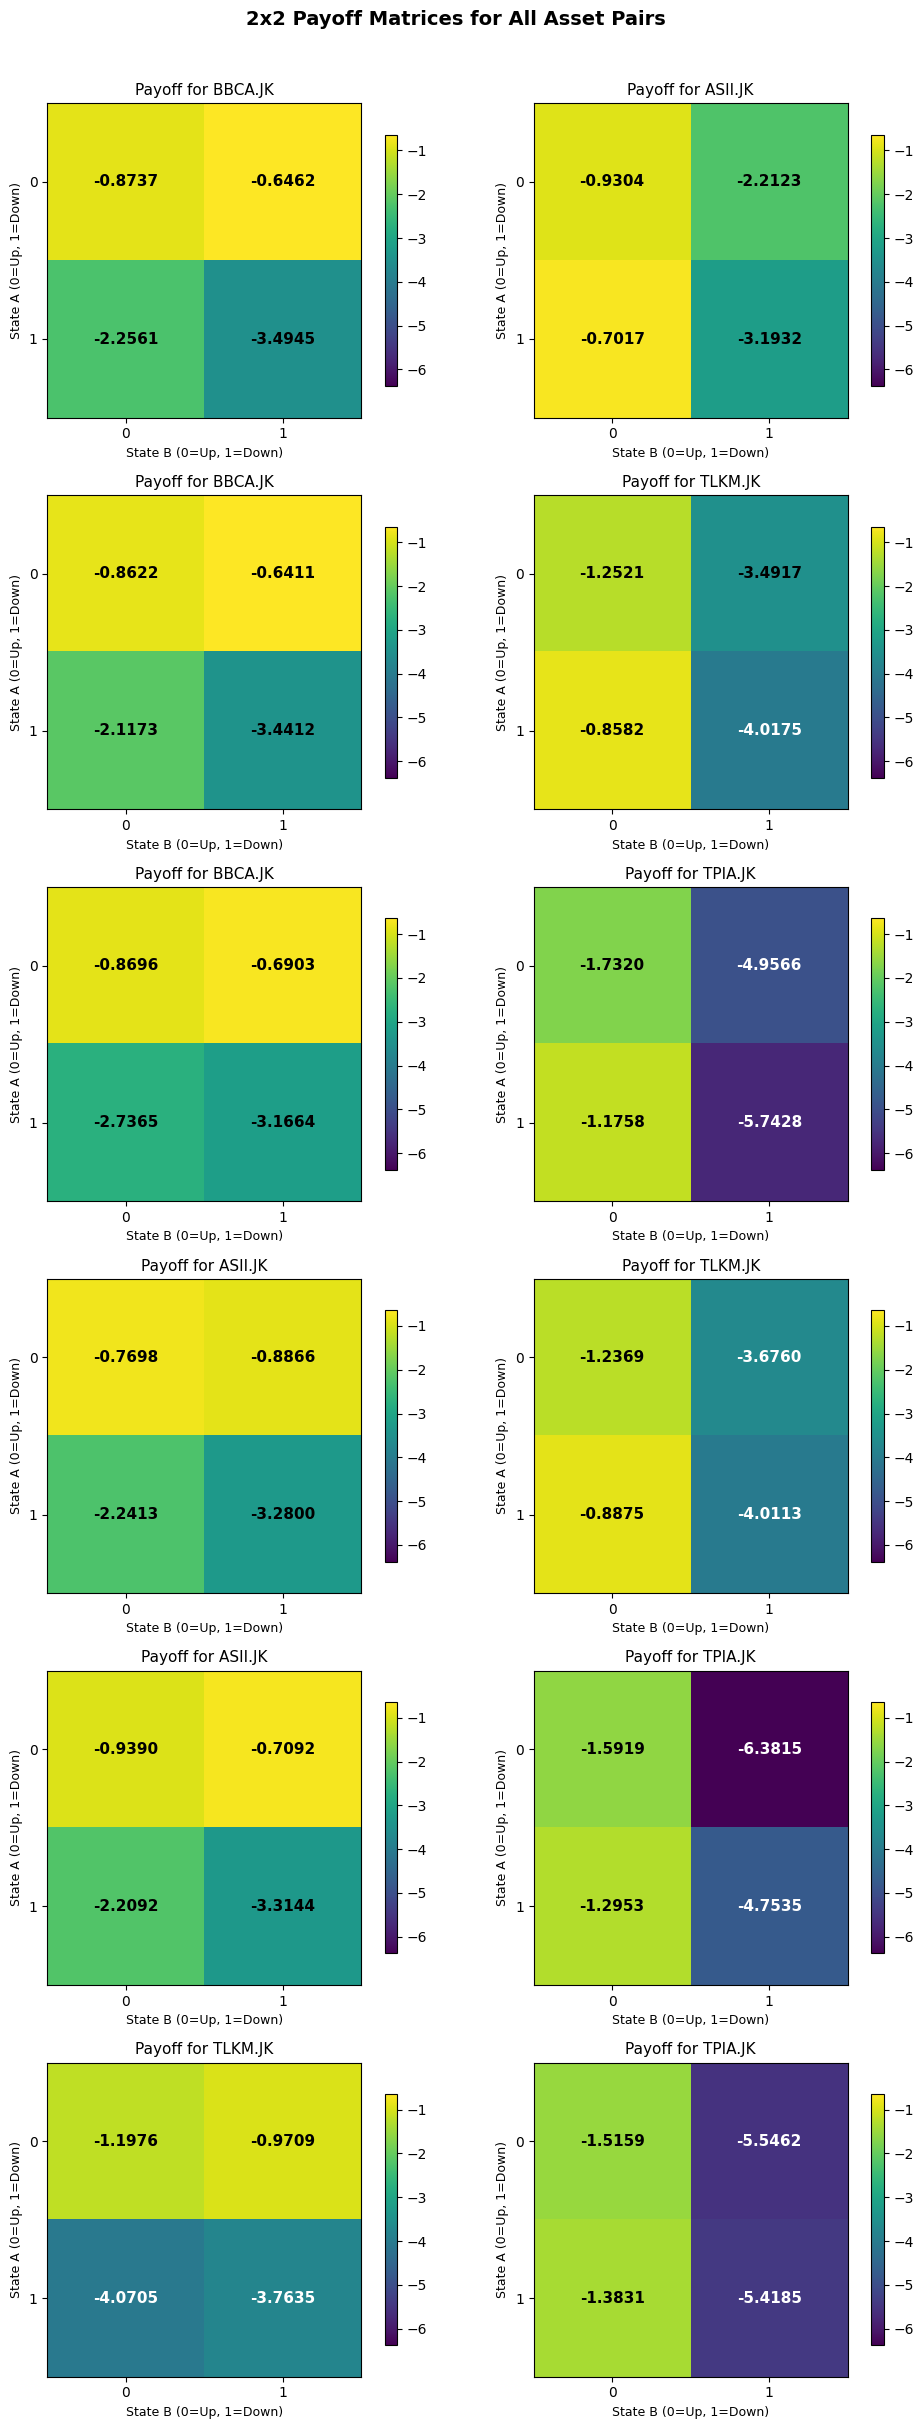

In [15]:
# 2b. Visualisasi 2×2 Payoff Matrices (Heatmap)

def plot_payoff_matrices(all_payoffs, tickers):
    """Visualisasi 2×2 payoff matrices sebagai heatmap."""
    pairs_list = list(all_payoffs.keys())
    n_pairs = len(pairs_list)
    
    fig, axes = plt.subplots(n_pairs, 2, figsize=(10, 4 * n_pairs))
    fig.suptitle('2x2 Payoff Matrices for All Asset Pairs', fontsize=14, fontweight='bold', y=1.01)
    
    # vmin/vmax global
    all_vals = []
    for (pA, pB) in all_payoffs.values():
        all_vals.extend(pA.flatten().tolist())
        all_vals.extend(pB.flatten().tolist())
    vmin, vmax = min(all_vals), max(all_vals)
    
    for row, (idx_a, idx_b) in enumerate(pairs_list):
        pA, pB = all_payoffs[(idx_a, idx_b)]
        a_name = tickers[idx_a]
        b_name = tickers[idx_b]
        
        for col, (payoff, name) in enumerate([(pA, a_name), (pB, b_name)]):
            ax = axes[row, col]
            im = ax.imshow(payoff, cmap='viridis', vmin=vmin, vmax=vmax, 
                          origin='upper', aspect='equal')
            
            for i in range(2):
                for j in range(2):
                    val = payoff[i, j]
                    color = 'white' if val < (vmin + vmax) / 2 else 'black'
                    ax.text(j, i, f'{val:.4f}', ha='center', va='center',
                           fontsize=11, fontweight='bold', color=color)
            
            ax.set_title(f'Payoff for {name}', fontsize=11)
            ax.set_xlabel('State B (0=Up, 1=Down)', fontsize=9)
            ax.set_ylabel('State A (0=Up, 1=Down)', fontsize=9)
            ax.set_xticks([0, 1])
            ax.set_yticks([0, 1])
            plt.colorbar(im, ax=ax, shrink=0.8)
    
    plt.tight_layout()
    plt.savefig('payoff_matrices_2x2.png', dpi=150, bbox_inches='tight')
    print("Plot saved: payoff_matrices_2x2.png")
    plt.show()

plot_payoff_matrices(all_payoffs, tickers)

---
## Tahap 3: Ekstraksi Parameter Hamiltonian

### Bias $h_i$ (dari Matriks Payoff)
$$h_i = (P_i[1,0] + P_i[1,1]) - (P_i[0,0] + P_i[0,1])$$

### Interaksi $J_{ij}$ (Quantum Mutual Information)
1. Bangun density matrix $\rho_{LF}$ dari probabilitas gabungan (Laplace Smoothing: $\alpha = 1$)
2. Von Neumann Entropy: $S(\rho) = -\text{Tr}(\rho \ln \rho)$
3. QMI: $J_{ij} = S(L) + S(F) - S(L,F)$

In [16]:
# 3. Ekstraksi Parameter Hamiltonian (h_i, J_ij via QMI)

def compute_bias_hi(all_payoffs, tickers):
    """Hitung bias h_i dari matriks payoff marginal."""
    n_assets = len(tickers)
    h = np.zeros(n_assets)
    for i in range(n_assets):
        payoff_sum = 0
        count = 0
        for (a, b), (pA, pB) in all_payoffs.items():
            if a == i:
                payoff_sum += (pA[1, 0] + pA[1, 1]) - (pA[0, 0] + pA[0, 1])
                count += 1
            elif b == i:
                payoff_sum += (pB[0, 1] + pB[1, 1]) - (pB[0, 0] + pB[1, 0])
                count += 1
        if count > 0:
            h[i] = payoff_sum / count
    return h


def compute_qmi_jij(binary_states, asset_a, asset_b, alpha=1.0):
    """Hitung Quantum Mutual Information (QMI) sebagai J_ij."""
    state_A = binary_states[asset_a].values
    state_B = binary_states[asset_b].values
    N = len(state_A)
    
    # Frekuensi dengan Laplace Smoothing
    n_ij = np.zeros((2, 2))
    for t in range(N):
        n_ij[state_A[t], state_B[t]] += 1
    prob_joint = (n_ij + alpha) / (N + 4 * alpha)
    
    # Density matrices
    rho_LF = np.diag(prob_joint.flatten())
    prob_L = prob_joint.sum(axis=1)
    rho_L = np.diag(prob_L)
    prob_F = prob_joint.sum(axis=0)
    rho_F = np.diag(prob_F)
    
    # Von Neumann Entropy
    def von_neumann_entropy(rho):
        eigenvalues = np.real(la.eigvalsh(rho))
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log(eigenvalues))
    
    S_LF = von_neumann_entropy(rho_LF)
    S_L = von_neumann_entropy(rho_L)
    S_F = von_neumann_entropy(rho_F)
    
    qmi = S_L + S_F - S_LF
    return qmi, prob_joint, S_L, S_F, S_LF


# Bias h_i
n_assets = len(tickers)
h = compute_bias_hi(all_payoffs, tickers)
print("Bias (h_i):")
for i, t in enumerate(tickers):
    interpretation = "cenderung dipilih" if h[i] < 0 else "kurang menarik"
    print(f"  h_{t} = {h[i]:.6f} ({interpretation})")

# Interaksi J_ij via QMI
J = np.zeros((n_assets, n_assets))
qmi_details = {}

print("\nInteraksi J_ij (Quantum Mutual Information):")
for i in range(n_assets):
    for j in range(i + 1, n_assets):
        qmi, prob_joint, S_L, S_F, S_LF = compute_qmi_jij(
            binary_states, tickers[i], tickers[j]
        )
        J[i, j] = qmi
        J[j, i] = qmi
        qmi_details[(i, j)] = {
            'qmi': qmi, 'prob': prob_joint,
            'S_L': S_L, 'S_F': S_F, 'S_LF': S_LF
        }
        
        sync = "tinggi (sinkron)" if qmi > 0.05 else "rendah (independen)"
        print(f"  J_{tickers[i]}_{tickers[j]} = {qmi:.6f} (korelasi {sync})")
        print(f"    S(L)={S_L:.4f}, S(F)={S_F:.4f}, S(L,F)={S_LF:.4f}")

Bias (h_i):
  h_BBCA.JK = -4.209643 (cenderung dipilih)
  h_ASII.JK = -3.837889 (cenderung dipilih)
  h_TLKM.JK = -5.542443 (cenderung dipilih)
  h_TPIA.JK = -8.034946 (cenderung dipilih)

Interaksi J_ij (Quantum Mutual Information):
  J_BBCA.JK_ASII.JK = 0.022531 (korelasi rendah (independen))
    S(L)=0.6798, S(F)=0.6927, S(L,F)=1.3500
  J_BBCA.JK_TLKM.JK = 0.050501 (korelasi tinggi (sinkron))
    S(L)=0.6798, S(F)=0.6906, S(L,F)=1.3199
  J_BBCA.JK_TPIA.JK = 0.012011 (korelasi rendah (independen))
    S(L)=0.6798, S(F)=0.6858, S(L,F)=1.3535
  J_ASII.JK_TLKM.JK = 0.014510 (korelasi rendah (independen))
    S(L)=0.6927, S(F)=0.6906, S(L,F)=1.3688
  J_ASII.JK_TPIA.JK = 0.005193 (korelasi rendah (independen))
    S(L)=0.6927, S(F)=0.6858, S(L,F)=1.3733
  J_TLKM.JK_TPIA.JK = 0.012214 (korelasi rendah (independen))
    S(L)=0.6906, S(F)=0.6858, S(L,F)=1.3642


---
## Tahap 4: Konstruksi Hamiltonian (Ising Model + Penalty)

**Cost Hamiltonian** (Profit & Risk via Game Theory):
$$H_{cost} = \sum_{i=1}^{4} h_i Z_i + \sum_{i<j} J_{ij} Z_i Z_j$$

**Constraint Hamiltonian** (Penalty Method, pilih tepat $K=2$):
$$H_{constraint} = A \left(\sum_{i=1}^{4} \frac{I - Z_i}{2} - K\right)^2$$

$$H_{total} = H_{cost} + H_{constraint}$$

In [17]:
# 4. Konstruksi Hamiltonian (Ising Model + Penalty)

def build_hamiltonian(h, J, n_assets=4, K=2, penalty_A=10.0):
    """Bangun Hamiltonian total = H_cost + H_constraint"""
    coeffs = []
    obs = []
    
    # H_cost: bias terms
    for i in range(n_assets):
        if abs(h[i]) > 1e-10:
            coeffs.append(float(h[i]))
            obs.append(qml.PauliZ(i))
    
    # H_cost: interaction terms
    for i in range(n_assets):
        for j in range(i + 1, n_assets):
            if abs(J[i, j]) > 1e-10:
                coeffs.append(float(J[i, j]))
                obs.append(qml.PauliZ(i) @ qml.PauliZ(j))
    
    # H_constraint: A·(Σ (I-Z_i)/2 - K)²
    N_half_minus_K = n_assets / 2 - K
    
    # Constant term
    const_term = penalty_A * (N_half_minus_K**2 + n_assets / 4)
    coeffs.append(float(const_term))
    obs.append(qml.Identity(0))
    
    # Linear terms: -A·(N/2-K)·Z_i
    for i in range(n_assets):
        coeffs.append(float(-penalty_A * N_half_minus_K))
        obs.append(qml.PauliZ(i))
    
    # Quadratic terms: A·(1/2)·Z_iZ_j
    for i in range(n_assets):
        for j in range(i + 1, n_assets):
            coeffs.append(float(penalty_A * 0.5))
            obs.append(qml.PauliZ(i) @ qml.PauliZ(j))
    
    H = qml.Hamiltonian(coeffs, obs)
    H = qml.simplify(H)
    return H


# Build Hamiltonian
H = build_hamiltonian(h, J, n_assets=len(tickers), K=K, penalty_A=penalty_A)
print(f"Hamiltonian terms: {len(H.ops)}")
print(f"H = {H}")

# Verifikasi: energi exact semua 2^4 = 16 states
print("\nEnergi untuk setiap bitstring:")
H_matrix = qml.matrix(H)
best_energy = float('inf')
best_state = None
for s in range(2**n_assets):
    bits = format(s, f'0{n_assets}b')
    energy = np.real(H_matrix[s, s])
    n_selected = bits.count('1')
    marker = ""
    if n_selected == K and energy < best_energy:
        best_energy = energy
        best_state = bits
        marker = " ← OPTIMAL"
    print(f"  |{bits}⟩: E = {energy:.4f}, selected = {n_selected}{marker}")

exact_state = best_state
exact_energy = best_energy
print(f"\nGround state (exact): |{exact_state}⟩ dengan E = {exact_energy:.4f}")

Hamiltonian terms: 11
H = -4.209642786794371 * Z(0) + -3.837888743009873 * Z(1) + -5.542442568880112 * Z(2) + -8.03494639990651 * Z(3) + 5.022530970429969 * (Z(0) @ Z(1)) + 5.050501168524573 * (Z(0) @ Z(2)) + 5.012010929018878 * (Z(0) @ Z(3)) + 5.014509567985324 * (Z(1) @ Z(2)) + 5.005193178110177 * (Z(1) @ Z(3)) + 5.012214132481523 * (Z(2) @ Z(3)) + 10.0 * I([0, 1, 2, 3])

Energi untuk setiap bitstring:
  |0000⟩: E = 18.4920, selected = 0
  |0001⟩: E = 4.5031, selected = 1
  |0010⟩: E = -0.5775, selected = 1
  |0011⟩: E = 5.4824, selected = 2 ← OPTIMAL
  |0100⟩: E = -3.9167, selected = 1
  |0101⟩: E = 2.1152, selected = 2 ← OPTIMAL
  |0110⟩: E = -2.9282, selected = 2 ← OPTIMAL
  |0111⟩: E = 23.1525, selected = 3
  |1000⟩: E = -3.2588, selected = 1
  |1001⟩: E = 2.8003, selected = 2
  |1010⟩: E = -2.1263, selected = 2
  |1011⟩: E = 23.9816, selected = 3
  |1100⟩: E = -5.5773, selected = 2 ← OPTIMAL
  |1101⟩: E = 20.5025, selected = 3
  |1110⟩: E = 15.6132, selected = 3
  |1111⟩: E = 61

---
## Tahap 5: Eksekusi HE-VQE dengan SPSA

**Ansatz (Sirkuit)**:
- 4 Qubit (satu per aset)
- Layer Rotasi: $R_Y(\theta)$ dan $R_Z(\phi)$ pada tiap qubit
- Layer Entanglement: CNOT chain ($0 \to 1, 1 \to 2, 2 \to 3, 3 \to 0$)
- Depth $d = 2$

**Optimizer SPSA**:
- Hanya 2 evaluasi fungsi per iterasi
- Gain sequences: $a_k = \frac{a}{(A+k+1)^\alpha}$, $c_k = \frac{c}{(k+1)^\gamma}$

Qubits: 4
Depth: 2
Parameters: 24
Optimizer: SPSA (250 iterasi)
Initial cost: 9.519151

Generating circuit image...


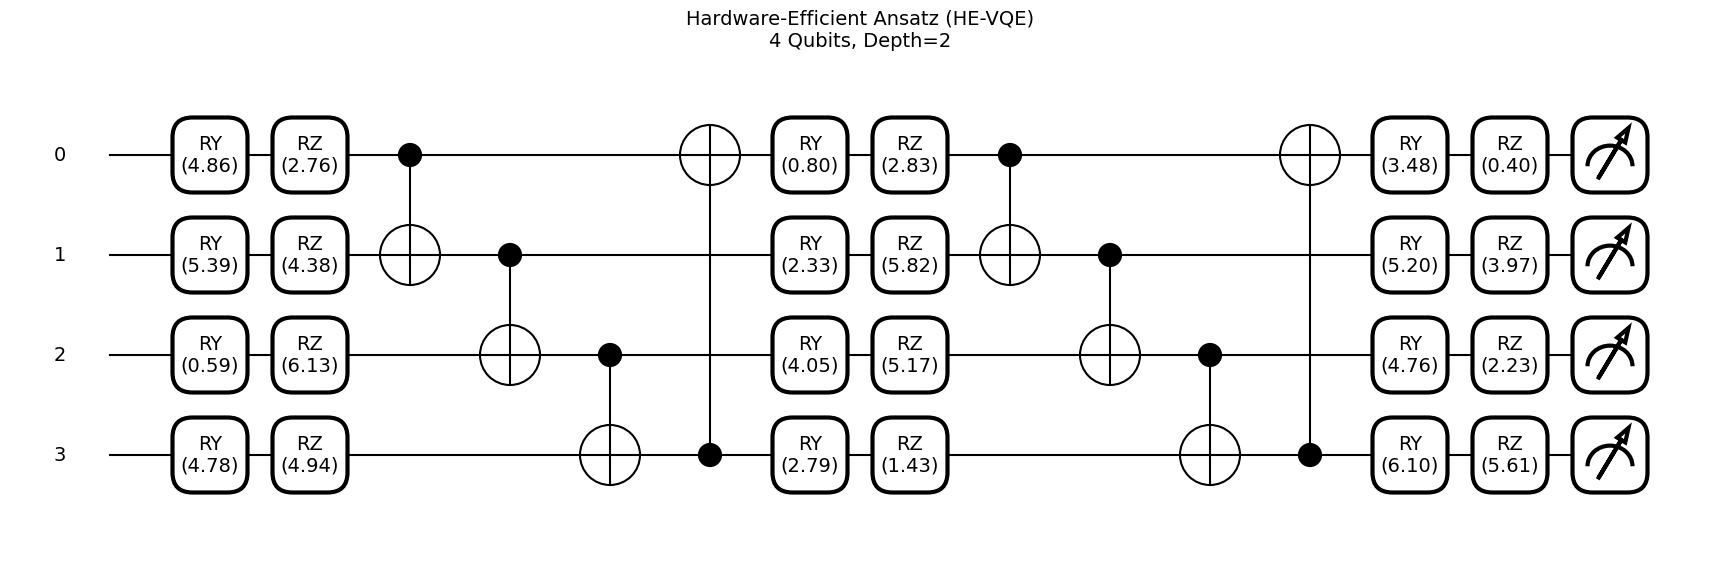


Memulai optimasi SPSA...
  Iter    0: E = 9.547359 (best = 9.547359)
  Iter   50: E = 5.221602 (best = 2.321230)
  Iter  100: E = 3.469161 (best = 2.321230)
  Iter  150: E = 4.481565 (best = 2.321230)
  Iter  200: E = 5.957460 (best = 2.022502)
  Iter  249: E = 5.400987 (best = 1.376630)

Optimasi selesai!
Best Energy: 1.376630
Total evaluasi fungsi: 500


In [18]:
# 5. Eksekusi HE-VQE dengan SPSA

n_qubits = len(tickers)
n_params = n_qubits * 2 * (depth + 1)  # 4 qubits × 2 (RY+RZ) × 3 layers = 24
rng = np.random.default_rng(seed)

print(f"Qubits: {n_qubits}")
print(f"Depth: {depth}")
print(f"Parameters: {n_params}")
print(f"Optimizer: SPSA ({maxiter} iterasi)")

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def vqe_circuit(params):
    """HE Ansatz: [Rot] - [CNOT] - [Rot] - [CNOT] - ... - [Rot]"""
    weights = params.reshape((depth + 1, n_qubits, 2))
    for layer in range(depth + 1):
        for q in range(n_qubits):
            qml.RY(weights[layer, q, 0], wires=q)
            qml.RZ(weights[layer, q, 1], wires=q)
        if layer < depth:
            for q in range(n_qubits):
                qml.CNOT(wires=[q, (q + 1) % n_qubits])
    return qml.expval(H)

def cost_fn(params):
    return float(vqe_circuit(params))

# Inisialisasi & kalibrasi
initial_params = rng.uniform(0, 2 * np.pi, n_params)
initial_cost = cost_fn(initial_params)
print(f"Initial cost: {initial_cost:.6f}")

# Visualisasi Sirkuit (Added)
print("\nGenerating circuit image...")
try:
    fig, ax = qml.draw_mpl(vqe_circuit, decimals=2)(initial_params)
    plt.title(f"Hardware-Efficient Ansatz (HE-VQE)\n{n_qubits} Qubits, Depth={depth}", fontsize=14)
    plt.show()
except Exception as e:
    print(f"  WARNING: Failed to generate circuit image: {e}")


# SPSA parameters (calibrated)
a = 0.1 * max(1.0, abs(initial_cost))
c = 0.10
A = maxiter * 0.1
alpha = 0.602
gamma = 0.101

params = initial_params.copy()
history = []
best_params = params.copy()
best_vqe_energy = float('inf')

print(f"\nMemulai optimasi SPSA...")
for k in range(maxiter):
    a_k = a / (A + k + 1) ** alpha
    c_k = c / (k + 1) ** gamma
    delta = 2 * rng.integers(0, 2, size=n_params) - 1
    
    f_plus = cost_fn(params + c_k * delta)
    f_minus = cost_fn(params - c_k * delta)
    
    grad = (f_plus - f_minus) / (2 * c_k * delta)
    params = params - a_k * grad
    
    cost_mid = (f_plus + f_minus) / 2
    history.append(cost_mid)
    
    if cost_mid < best_vqe_energy:
        best_vqe_energy = cost_mid
        best_params = params.copy()
    
    if k % 50 == 0 or k == maxiter - 1:
        print(f"  Iter {k:4d}: E = {cost_mid:.6f} (best = {best_vqe_energy:.6f})")

print(f"\nOptimasi selesai!")
print(f"Best Energy: {best_vqe_energy:.6f}")
print(f"Total evaluasi fungsi: {2 * maxiter}")

In [19]:
# 5b. Sampling Akhir

print(f"Sampling {n_shots} shots dari sirkuit optimal...")

dev_sample = qml.device("default.qubit", wires=n_qubits, shots=n_shots)

@qml.qnode(dev_sample)
def sample_circuit(params):
    weights = params.reshape((depth + 1, n_qubits, 2))
    for layer in range(depth + 1):
        for q in range(n_qubits):
            qml.RY(weights[layer, q, 0], wires=q)
            qml.RZ(weights[layer, q, 1], wires=q)
        if layer < depth:
            for q in range(n_qubits):
                qml.CNOT(wires=[q, (q + 1) % n_qubits])
    return qml.probs(wires=range(n_qubits))

probs = sample_circuit(best_params)

# Distribusi state
print("\nDistribusi State (top 10):")
state_probs = []
for s in range(2**n_qubits):
    bits = format(s, f'0{n_qubits}b')
    state_probs.append((bits, float(probs[s])))

state_probs.sort(key=lambda x: x[1], reverse=True)
for bits, prob in state_probs[:10]:
    n_sel = bits.count('1')
    bar = "█" * int(prob * 50)
    print(f"  |{bits}⟩: {prob:.4f} {bar} (selected={n_sel})")

Sampling 4096 shots dari sirkuit optimal...

Distribusi State (top 10):
  |1000⟩: 0.1975 █████████ (selected=1)
  |1001⟩: 0.1401 ███████ (selected=2)
  |0010⟩: 0.1377 ██████ (selected=1)
  |0110⟩: 0.1250 ██████ (selected=2)
  |1100⟩: 0.0867 ████ (selected=2)
  |0001⟩: 0.0637 ███ (selected=1)
  |1010⟩: 0.0542 ██ (selected=2)
  |1101⟩: 0.0422 ██ (selected=3)
  |0111⟩: 0.0405 ██ (selected=3)
  |0011⟩: 0.0349 █ (selected=2)


---
## Tahap 6: Hasil & Analisis

1. **Identifikasi bitstring** dengan probabilitas tertinggi (tepat 2 bit "1")
2. **Sharpe Ratio** portofolio terpilih vs semua pasangan lain
3. **Visualisasi**: Konvergensi VQE, Distribusi State, Sharpe Ratio

In [20]:
# 6. Hasil & Analisis

# Identifikasi bitstring terbaik (tepat 2 aset)
best_bitstring = None
best_prob = 0
for bits, prob in state_probs:
    if bits.count('1') == 2 and prob > best_prob:
        best_bitstring = bits
        best_prob = prob

if best_bitstring is None:
    best_bitstring = state_probs[0][0]
    best_prob = state_probs[0][1]

selected_indices = [i for i, b in enumerate(best_bitstring) if b == '1']
selected_assets = [tickers[i] for i in selected_indices]

print(f"Bitstring optimal: |{best_bitstring}⟩ (prob = {best_prob:.4f})")
print(f"Exact ground state: |{exact_state}⟩")
print(f"Match: {'✓ YES' if best_bitstring == exact_state else '✗ NO'}")
print(f"\n★ ASET TERPILIH: {selected_assets}")

# Sharpe Ratio validasi
print(f"\nValidasi Sharpe Ratio:")
rf = 0.0 #risk-free rate rate
all_pairs = list(combinations(range(len(tickers)), 2))
sharpe_dict = {}
for i, j in all_pairs:
    pair_return = (log_returns[tickers[i]] + log_returns[tickers[j]]) / 2
    mu = pair_return.mean() * 252
    sigma = pair_return.std() * np.sqrt(252)
    sharpe = (mu - rf) / sigma if sigma > 0 else 0
    sharpe_dict[(i, j)] = sharpe
    selected_marker = " ★" if set([i, j]) == set(selected_indices) else ""
    print(f"  {tickers[i]} + {tickers[j]}: Sharpe = {sharpe:.4f}{selected_marker}")

# Energi comparison
print(f"\nEnergi:")
print(f"  VQE:   {best_vqe_energy:.6f}")
print(f"  Exact: {exact_energy:.6f}")
print(f"  Error: {abs(best_vqe_energy - exact_energy):.6f}")

Bitstring optimal: |1001⟩ (prob = 0.1401)
Exact ground state: |1100⟩
Match: ✗ NO

★ ASET TERPILIH: ['BBCA.JK', 'TPIA.JK']

Validasi Sharpe Ratio:
  BBCA.JK + ASII.JK: Sharpe = 0.6280
  BBCA.JK + TLKM.JK: Sharpe = 0.4117
  BBCA.JK + TPIA.JK: Sharpe = -0.1538 ★
  ASII.JK + TLKM.JK: Sharpe = 1.6145
  ASII.JK + TPIA.JK: Sharpe = 0.7067
  TLKM.JK + TPIA.JK: Sharpe = 0.5679

Energi:
  VQE:   1.376630
  Exact: -5.577327
  Error: 6.953957


Plot saved: econophysics_vqe_results.png


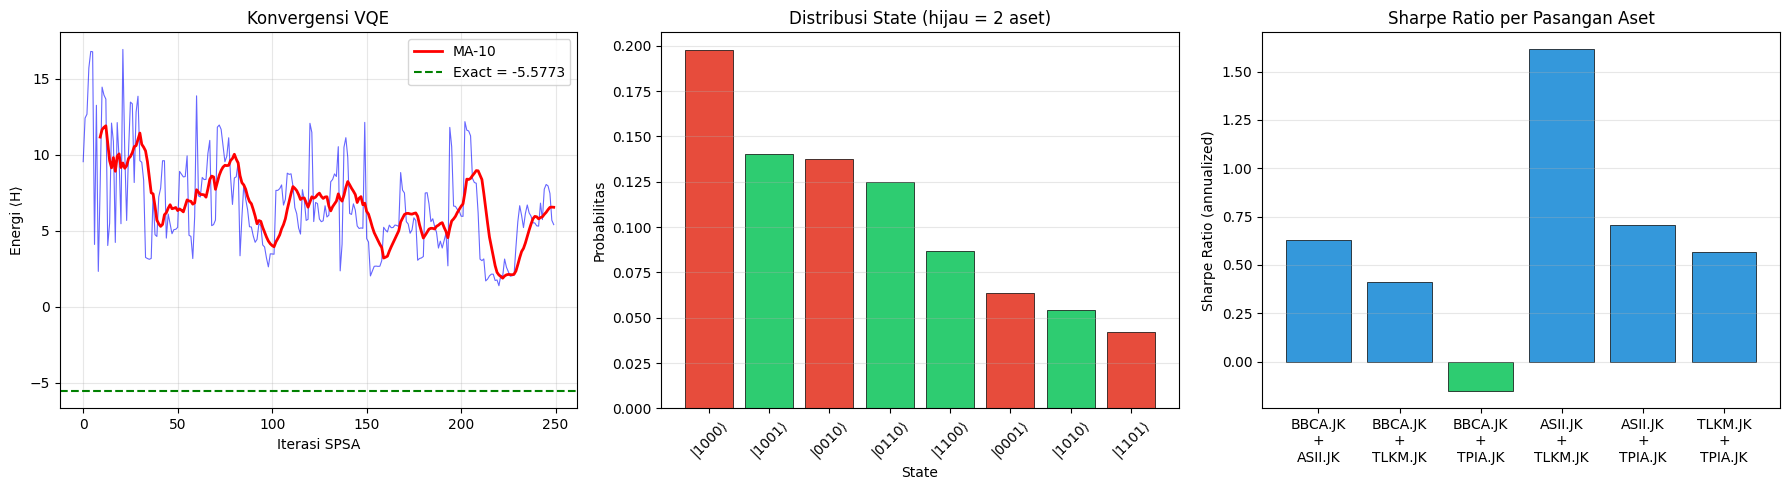

In [21]:
# 6b. Visualisasi

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Konvergensi VQE
ax1 = axes[0]
ax1.plot(history, 'b-', alpha=0.6, linewidth=0.8)
window = 10
if len(history) > window:
    ma = np.convolve(history, np.ones(window)/window, mode='valid')
    ax1.plot(range(window-1, len(history)), ma, 'r-', linewidth=2, label=f'MA-{window}')
ax1.axhline(y=exact_energy, color='g', linestyle='--', label=f'Exact = {exact_energy:.4f}')
ax1.set_xlabel('Iterasi SPSA')
ax1.set_ylabel('Energi ⟨H⟩')
ax1.set_title('Konvergensi VQE')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Distribusi State
ax2 = axes[1]
top_states = state_probs[:8]
labels = [f"|{b}⟩" for b, _ in top_states]
probs_plot = [p for _, p in top_states]
colors = ['#2ecc71' if b.count('1') == 2 else '#e74c3c' for b, _ in top_states]
ax2.bar(labels, probs_plot, color=colors, edgecolor='black', linewidth=0.5)
ax2.set_xlabel('State')
ax2.set_ylabel('Probabilitas')
ax2.set_title('Distribusi State (hijau = 2 aset)')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Sharpe Ratio
ax3 = axes[2]
pair_labels = [f"{tickers[i]}\n+\n{tickers[j]}" for i, j in all_pairs]
sharpe_vals = [sharpe_dict[pair] for pair in all_pairs]
colors_sharpe = ['#2ecc71' if set(pair) == set(selected_indices) else '#3498db' 
                 for pair in all_pairs]
ax3.bar(pair_labels, sharpe_vals, color=colors_sharpe, edgecolor='black', linewidth=0.5)
ax3.set_ylabel('Sharpe Ratio (annualized)')
ax3.set_title('Sharpe Ratio per Pasangan Aset')
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('econophysics_vqe_results.png', dpi=150, bbox_inches='tight')
print("Plot saved: econophysics_vqe_results.png")
plt.show()

In [22]:
# Ringkasan Akhir

print("╔" + "═" * 68 + "╗")
print("║                        RINGKASAN AKHIR                            ║")
print("╠" + "═" * 68 + "╣")
print(f"║  Aset Input:  {', '.join(tickers):<54}║")
print(f"║  λ_market:    {lambda_risk:.4f} (endogen dari data){' ':<36}║")
print(f"║  VQE Energy:  {best_vqe_energy:.6f}{' ':<46}║")
print(f"║  Exact Energy: {exact_energy:.6f}{' ':<45}║")
sel_str = f"{selected_assets[0]} & {selected_assets[1]}"
print(f"║  ★ Terpilih:  {sel_str:<54}║")
print("╚" + "═" * 68 + "╝")

╔════════════════════════════════════════════════════════════════════╗
║                        RINGKASAN AKHIR                            ║
╠════════════════════════════════════════════════════════════════════╣
║  Aset Input:  BBCA.JK, ASII.JK, TLKM.JK, TPIA.JK                    ║
║  λ_market:    0.6025 (endogen dari data)                                    ║
║  VQE Energy:  1.376630                                              ║
║  Exact Energy: -5.577327                                             ║
║  ★ Terpilih:  BBCA.JK & TPIA.JK                                     ║
╚════════════════════════════════════════════════════════════════════╝
